# letra O

In [1]:
import pandas as pd

df = pd.read_csv('clientes_atencao_0106.csv')
print(df.shape)
df.head()

(32, 12)


,Unnamed: 0,Cód Cliente,Cliente,Fat/dia Jan-Mar 2026,Fat/dia Atual,Fat/dia Projetado,Δ vs Jan-Mar 2026 %,MC/dia Jan-Mar 2026,MC/dia Atual,MC/dia Projetada,Δ MC R$/dia,Δ MC %
0,31,I7267,TNET AUTO PECAS LTDA,780.19,0.0,0.0,-100.0,104.26,0.0,0.0,-104.26,NaN
1,19,I2897,CAIRO MAGALHAES PIMENTA,27.95,0.0,0.0,-100.0,0.47,0.0,0.0,-0.47,NaN
2,18,I2140,RODRIGUES BRAGA PECAS E ACESSORIOS LTDA,32.49,0.0,0.0,-100.0,1.33,0.0,0.0,-1.33,NaN
3,16,I1937,OPEN AUTO CENTER LTDA,168.34,0.0,0.0,-100.0,19.52,0.0,0.0,-19.52,NaN
4,30,I6127,GT DISTRIBUIDORA DE AUTO PECAS LTDA,3.02,0.0,0.0,-100.0,0.35,0.0,0.0,-0.35,NaN


In [2]:
print(df.columns.tolist())

# Garante que Δ MC R$/dia é numérico
df['Δ MC R$/dia'] = pd.to_numeric(df['Δ MC R$/dia'], errors='coerce')

# Filtra só quem teve queda real (valor negativo)
df_queda = df[df['Δ MC R$/dia'] < 0].copy()
df_queda = df_queda.sort_values('Δ MC R$/dia', ascending=True)  # mais negativo primeiro

print(f"Total de clientes com queda: {len(df_queda)}")
print(f"Queda total de MC: R$ {df_queda['Δ MC R$/dia'].sum():.0f}/dia")
df_queda.head()

['Unnamed: 0', 'Cód Cliente', 'Cliente', 'Fat/dia Jan-Mar 2026', 'Fat/dia Atual', 'Fat/dia Projetado', 'Δ vs Jan-Mar 2026 %', 'MC/dia Jan-Mar 2026', 'MC/dia Atual', 'MC/dia Projetada', 'Δ MC R$/dia', 'Δ MC %']
Total de clientes com queda: 25
Queda total de MC: R$ -500/dia


,Unnamed: 0,Cód Cliente,Cliente,Fat/dia Jan-Mar 2026,Fat/dia Atual,Fat/dia Projetado,Δ vs Jan-Mar 2026 %,MC/dia Jan-Mar 2026,MC/dia Atual,MC/dia Projetada,Δ MC R$/dia,Δ MC %
0,31,I7267,TNET AUTO PECAS LTDA,780.19,0.00,0.00,-100.000000,104.26,0.00,0.00,-104.26,NaN
8,21,I2933,ANA CRISTINA DE OLIVEIRA,512.15,66.86,66.86,-86.945231,71.54,6.76,6.76,-64.78,2.627747e-14
7,8,27408,KADOSH CENTRO AUTOMOTIVO LTDA,769.68,99.46,99.46,-87.077747,73.30,10.85,10.85,-62.45,1.637195e-14
9,12,I1520,IOBERTO ALVES DOS SANTOS JUNIOR LTDA,441.05,75.04,75.04,-82.986056,50.08,15.51,15.51,-34.57,0.000000e+00
23,29,I6087,KD AUTO PECAS LTDA,450.15,296.74,296.74,-34.079751,61.85,32.46,32.46,-29.39,0.000000e+00


In [3]:
total_queda = df_queda['Δ MC R$/dia'].sum()
meta_80 = total_queda * 0.80

df_queda['queda_acum'] = df_queda['Δ MC R$/dia'].cumsum()
df_queda['pct_acum'] = df_queda['queda_acum'] / total_queda * 100

# Grupo 80% — os primeiros clientes até atingir 80% da queda
grupo_80 = df_queda[df_queda['pct_acum'] <= 80].copy()
grupo_20 = df_queda[df_queda['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80)} clientes — R$ {grupo_80['Δ MC R$/dia'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20)} clientes — R$ {grupo_20['Δ MC R$/dia'].sum():.0f}/dia de queda")

Grupo 80%: 9 clientes — R$ -389/dia de queda
Grupo 20%: 16 clientes — R$ -110/dia de queda


In [4]:
print(f"Total queda: {total_queda:.0f}")
print(f"Meta 80%: {meta_80:.0f}")
print(df_queda[['Cliente','Δ MC R$/dia','queda_acum','pct_acum']].head(10))

Total queda: -500
Meta 80%: -400
                                     Cliente  Δ MC R$/dia  queda_acum  \
0                       TNET AUTO PECAS LTDA      -104.26     -104.26   
8                   ANA CRISTINA DE OLIVEIRA       -64.78     -169.04   
7              KADOSH CENTRO AUTOMOTIVO LTDA       -62.45     -231.49   
9       IOBERTO ALVES DOS SANTOS JUNIOR LTDA       -34.57     -266.06   
23                        KD AUTO PECAS LTDA       -29.39     -295.45   
13                 SMM PECAS E SERVICOS LTDA       -27.32     -322.77   
24  AUTO CARS EXPRESS CENTRO AUTOMOTIVO LTDA       -23.39     -346.16   
27                    PACOTAO DAS PECAS LTDA       -23.38     -369.54   
3                      OPEN AUTO CENTER LTDA       -19.52     -389.06   
12                       ALTERNATIVATEM LTDA       -18.91     -407.97   

     pct_acum  
0   20.871619  
8   33.839809  
7   46.341561  
9   53.262066  
23  59.145597  
13  64.614738  
24  69.297139  
27  73.977539  
3   77.885212  
12 

In [5]:
# Salvar os grupos
grupo_80.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_O.csv', index=False)
grupo_20.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_O.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80[['Cód Cliente','Cliente','Δ MC R$/dia','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
Cód Cliente                                  Cliente  Δ MC R$/dia  pct_acum
      I7267                     TNET AUTO PECAS LTDA      -104.26 20.871619
      I2933                 ANA CRISTINA DE OLIVEIRA       -64.78 33.839809
      27408            KADOSH CENTRO AUTOMOTIVO LTDA       -62.45 46.341561
      I1520     IOBERTO ALVES DOS SANTOS JUNIOR LTDA       -34.57 53.262066
      I6087                       KD AUTO PECAS LTDA       -29.39 59.145597
      I1891                SMM PECAS E SERVICOS LTDA       -27.32 64.614738
      I2952 AUTO CARS EXPRESS CENTRO AUTOMOTIVO LTDA       -23.39 69.297139
      24237                   PACOTAO DAS PECAS LTDA       -23.38 73.977539
      I1937                    OPEN AUTO CENTER LTDA       -19.52 77.885212


In [6]:
# USANDO CLI_FORN
cf = pd.read_csv('cli_forn.csv')
cf['Δ vl_d'] = cf['d_vl_d'] - cf['a_vl_d']
cf['Δ vl_pct'] = (cf['Δ vl_d'] / cf['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 9 clientes do grupo 80%
codigos_80 = grupo_80['Cód Cliente'].astype(str).tolist()
cf_80 = cf[cf['codcli'].astype(str).isin(codigos_80)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80)}")
cf_80.head()

Registros encontrados no cli_forn: 483


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
1499,24237,O,PACOTAO DAS PECAS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,0.84,0.60,0.15,1,5.47,4.02,0.84,2,4.63,551.190476
1500,24237,O,PACOTAO DAS PECAS LTDA,55,OSPINA IND DE AUTO PECAS LTDA,OSPINA,0.96,0.59,0.26,1,0.00,0.00,0.00,0,-0.96,-100.000000
1501,24237,O,PACOTAO DAS PECAS LTDA,76,EDANTI IND COM PECAS PARA AUTOS LTDA,EDANTI,0.21,0.12,0.07,2,0.00,0.00,0.00,0,-0.21,-100.000000
1502,24237,O,PACOTAO DAS PECAS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,39.01,28.90,5.95,49,28.49,20.96,3.68,10,-10.52,-26.967444
1503,24237,O,PACOTAO DAS PECAS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,12.46,8.56,2.50,11,1.21,0.76,0.30,1,-11.25,-90.288925


In [7]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão     CV  Zeraram        Tipo
 I1937                    OPEN AUTO CENTER LTDA              29         -100.0            0.0   0.00       29 Normalizada
 I7267                     TNET AUTO PECAS LTDA              75         -100.0            0.0   0.00       75 Normalizada
 27408            KADOSH CENTRO AUTOMOTIVO LTDA              54          -76.1           55.7   0.73       38 Concentrada
 I2933                 ANA CRISTINA DE OLIVEIRA              49          -80.7           63.3   0.78       42 Concentrada
 I1891                SMM PECAS E SERVICOS LTDA              49          -67.6           71.8   1.06       34 Concentrada
 I6087                       KD AUTO PECAS LTDA              47          -56.6           74.8   1.32       30 Concentrada
 I1520     IOBERTO ALVES DOS SANTOS JUNIOR LTDA              43          -39.7          205.6   5.17       30 Concentrada
 I2952 AUTO CARS EXPRESS

In [8]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = '27408'

for codcli, grupo in cf_80.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"{nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


KADOSH CENTRO AUTOMOTIVO LTDA (27408)
Queda média: -76.1% | Desvio: 55.7 | CV: 0.73 | Fornecedores: 54
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
3RHO                              2.28         0.00     -100.0% 🔴 Zerou
MTA                               1.53         0.00     -100.0% 🔴 Zerou
ROLTENS                           1.94         0.00     -100.0% 🔴 Zerou
BOSCH                            17.25         0.00     -100.0% 🔴 Zerou
SUN ELETRI                        2.44         0.00     -100.0% 🔴 Zerou
VALEO                             5.33         0.00     -100.0% 🔴 Zerou
RAINHA DA                         0.17         0.00     -100.0% 🔴 Zerou
FLORIO                            8.28         0.00     -100.0% 🔴 Zerou
TSA                               0.79         0.00     -100.0% 🔴 Zerou
RADNAQ                            0.70         0.00     -100.0% 🔴 Zerou
DPL                               2

In [9]:
with pd.ExcelWriter('analise_clientes_80_O.xlsx') as writer:
    # Aba resumo
    df_resumo.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [10]:
from collections import Counter

clientes_concentrados = df_resumo[df_resumo['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados = {}
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod].copy()
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod] = set(zerados)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados = [f for zerados in fornecedores_zerados.values() for f in zerados]
contagem = Counter(todos_zerados)

# Só os que aparecem em mais de 1 cliente
em_comum = {k: v for k, v in contagem.items() if v > 1}
df_comum = pd.DataFrame(em_comum.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

C:\Users\priscila.marques\AppData\Local\Temp\ipykernel_9364\1615619063.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)


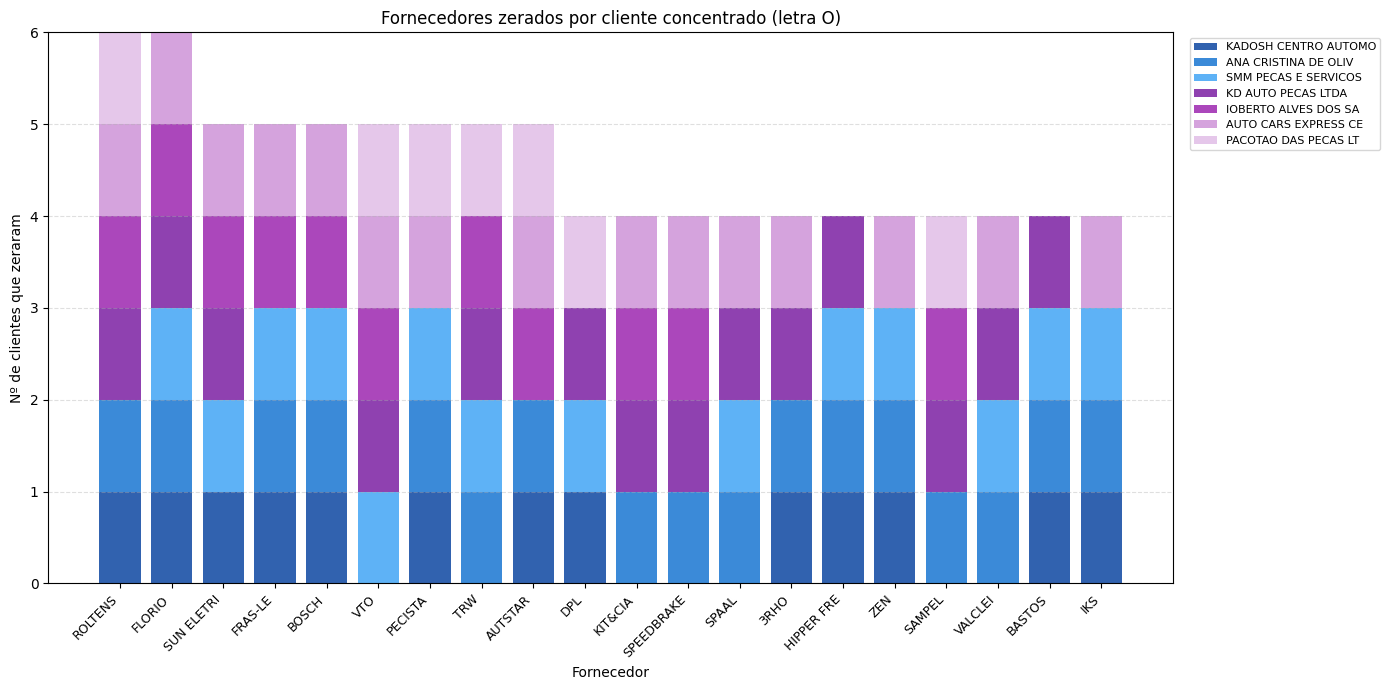

In [11]:
import matplotlib.pyplot as plt
import numpy as np

top_forn = df_comum.head(20)['Fornecedor'].tolist()

cores_clientes = {
    cod: cor for cod, cor in zip(
        clientes_concentrados,
        ['#0d47a1','#1976d2','#42a5f5','#7b1fa2','#9c27b0','#ce93d8','#e1bee7']
    )
}

fig, ax = plt.subplots(figsize=(14, 7))

bottom = np.zeros(len(top_forn))
for cod in clientes_concentrados:
    sub = cf_80[cf_80['codcli'].astype(str) == cod]
    nome = sub['nome'].iloc[0][:20]
    zerados = sub[sub['d_vl_d'] == 0]['fantasia'].tolist()
    valores = [1 if f in zerados else 0 for f in top_forn]
    
    ax.bar(top_forn, valores, bottom=bottom,
           color=cores_clientes[cod], label=nome, alpha=0.85)
    bottom += np.array(valores)

ax.set_xlabel("Fornecedor")
ax.set_ylabel("Nº de clientes que zeraram")
ax.set_title("Fornecedores zerados por cliente concentrado (letra O)", fontsize=12)
ax.set_xticklabels(top_forn, rotation=45, ha='right', fontsize=9)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('barras_fornecedores_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

# Letra Q

In [12]:
import pandas as pd

Q = pd.read_csv('clientes_Q_atencao.csv')
print(Q.shape)
Q.head()

(11, 12)


,Unnamed: 0,Cód Cliente,Cliente,Fat/dia Jan-Mar 2026,Fat/dia Atual,Fat/dia Projetado,Δ vs Jan-Mar 2026 %,MC/dia Jan-Mar 2026,MC/dia Atual,MC/dia Projetada,Δ MC R$/dia,Δ MC %
0,7,I4352,FARIAS AUTO CENTER LTDA,50.11,0.00,0.00,-100.000000,7.10,0.00,0.00,-7.10,NaN
1,1,27566,WILMAR SOUSA DO NASCIMENTO ME,192.94,22.47,22.47,-88.353892,7.69,1.08,1.08,-6.61,-8.223874e-14
2,6,I2964,GERLANDIA MARIA GOMES DA SILVA E CIA LTD,198.67,43.48,43.48,-78.114461,25.69,5.53,5.53,-20.16,1.606109e-14
3,10,I5901,BETO BATERIAS E AUTO ELETRICA LTDA,158.77,89.42,89.42,-43.679536,19.85,13.63,13.63,-6.22,1.303270e-14
4,3,I2385,AUTO ELETRICA E ACESSORIOS TREVAO LTDA,172.12,106.22,106.22,-38.287241,6.86,5.11,5.11,-1.75,0.000000e+00


In [13]:
print(Q.columns.tolist())

# Garante que Δ MC R$/dia é numérico
Q['Δ MC R$/dia'] = pd.to_numeric(Q['Δ MC R$/dia'], errors='coerce')

# Filtra só quem teve queda real (valor negativo)
Q_queda = Q[Q['Δ MC R$/dia'] < 0].copy()
Q_queda = Q_queda.sort_values('Δ MC R$/dia', ascending=True)  # mais negativo primeiro

print(f"Total de clientes com queda: {len(Q_queda)}")
print(f"Queda total de MC: R$ {Q_queda['Δ MC R$/dia'].sum():.0f}/dia")
Q_queda.head()

['Unnamed: 0', 'Cód Cliente', 'Cliente', 'Fat/dia Jan-Mar 2026', 'Fat/dia Atual', 'Fat/dia Projetado', 'Δ vs Jan-Mar 2026 %', 'MC/dia Jan-Mar 2026', 'MC/dia Atual', 'MC/dia Projetada', 'Δ MC R$/dia', 'Δ MC %']
Total de clientes com queda: 10
Queda total de MC: R$ -67/dia


,Unnamed: 0,Cód Cliente,Cliente,Fat/dia Jan-Mar 2026,Fat/dia Atual,Fat/dia Projetado,Δ vs Jan-Mar 2026 %,MC/dia Jan-Mar 2026,MC/dia Atual,MC/dia Projetada,Δ MC R$/dia,Δ MC %
2,6,I2964,GERLANDIA MARIA GOMES DA SILVA E CIA LTD,198.67,43.48,43.48,-78.114461,25.69,5.53,5.53,-20.16,1.606109e-14
8,0,24165,AUTO ELETRICA QUIRINOPOLIS LTDA,577.53,476.16,476.16,-17.552335,55.47,43.18,43.18,-12.29,-1.645537e-14
6,5,I2621,SOPEL SO PECAS ELETRICAS LTDA,852.11,604.34,604.34,-29.077232,74.01,65.09,65.09,-8.92,0.000000e+00
0,7,I4352,FARIAS AUTO CENTER LTDA,50.11,0.00,0.00,-100.000000,7.10,0.00,0.00,-7.10,NaN
1,1,27566,WILMAR SOUSA DO NASCIMENTO ME,192.94,22.47,22.47,-88.353892,7.69,1.08,1.08,-6.61,-8.223874e-14


In [14]:
Q_total_queda = Q_queda['Δ MC R$/dia'].sum()
meta_80_Q = Q_total_queda * 0.80

Q_queda['queda_acum'] = Q_queda['Δ MC R$/dia'].cumsum()
Q_queda['pct_acum'] = Q_queda['queda_acum'] / Q_total_queda * 100

# Grupo 80% — os primeiros clientes até atingir 80% da queda
grupo_80_Q = Q_queda[Q_queda['pct_acum'] <= 80].copy()
grupo_20_Q = Q_queda[Q_queda['pct_acum'] > 80].copy()

print(f"Grupo 80%: {len(grupo_80_Q)} clientes — R$ {grupo_80_Q['Δ MC R$/dia'].sum():.0f}/dia de queda")
print(f"Grupo 20%: {len(grupo_20_Q)} clientes — R$ {grupo_20_Q['Δ MC R$/dia'].sum():.0f}/dia de queda")

Grupo 80%: 4 clientes — R$ -48/dia de queda
Grupo 20%: 6 clientes — R$ -19/dia de queda


In [15]:
print(f"Total queda: {Q_total_queda:.0f}")
print(f"Meta 80%: {meta_80:.0f}")
print(Q_queda[['Cliente','Δ MC R$/dia','queda_acum','pct_acum']].head(10))

Total queda: -67
Meta 80%: -400
                                     Cliente  Δ MC R$/dia  queda_acum  \
2   GERLANDIA MARIA GOMES DA SILVA E CIA LTD       -20.16      -20.16   
8            AUTO ELETRICA QUIRINOPOLIS LTDA       -12.29      -32.45   
6              SOPEL SO PECAS ELETRICAS LTDA        -8.92      -41.37   
0                    FARIAS AUTO CENTER LTDA        -7.10      -48.47   
1              WILMAR SOUSA DO NASCIMENTO ME        -6.61      -55.08   
3         BETO BATERIAS E AUTO ELETRICA LTDA        -6.22      -61.30   
10                OESTE PECAS ELETRICAS LTDA        -1.82      -63.12   
4     AUTO ELETRICA E ACESSORIOS TREVAO LTDA        -1.75      -64.87   
5                      DOMINGOS MINEIRO LTDA        -1.74      -66.61   
7           BATERPECAS BATERIAS E PECAS LTDA        -0.79      -67.40   

      pct_acum  
2    29.910979  
8    48.145401  
6    61.379822  
0    71.913947  
1    81.721068  
3    90.949555  
10   93.649852  
4    96.246291  
5    98.827

In [16]:
# Salvar os grupos
grupo_80_Q.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_80_atencao_Q.csv', index=False)
grupo_20_Q.drop(columns=['queda_acum','pct_acum']).to_csv('clientes_20_atencao_Q.csv', index=False)

print("\nGrupo 80% — clientes prioritários:")
print(grupo_80_Q[['Cód Cliente','Cliente','Δ MC R$/dia','pct_acum']].to_string(index=False))


Grupo 80% — clientes prioritários:
Cód Cliente                                  Cliente  Δ MC R$/dia  pct_acum
      I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD       -20.16 29.910979
      24165          AUTO ELETRICA QUIRINOPOLIS LTDA       -12.29 48.145401
      I2621            SOPEL SO PECAS ELETRICAS LTDA        -8.92 61.379822
      I4352                  FARIAS AUTO CENTER LTDA        -7.10 71.913947


In [17]:
# USANDO CLI_FORN
cf_Q = pd.read_csv('cli_forn.csv')
cf_Q['Δ vl_d'] = cf_Q['d_vl_d'] - cf_Q['a_vl_d']
cf_Q['Δ vl_pct'] = (cf_Q['Δ vl_d'] / cf_Q['a_vl_d'].replace(0, float('nan'))) * 100

# Filtra só os 9 clientes do grupo 80%
codigos_80_Q = grupo_80_Q['Cód Cliente'].astype(str).tolist()
cf_80_Q = cf_Q[cf_Q['codcli'].astype(str).isin(codigos_80_Q)].copy()

print(f"Registros encontrados no cli_forn: {len(cf_80_Q)}")
cf_80_Q.head()

Registros encontrados no cli_forn: 139


,codcli,sigla,nome,codfor,fornecedor,fantasia,a_vl_d,a_cmv_d,a_mc_d,a_qtde,d_vl_d,d_cmv_d,d_mc_d,d_qtde,Δ vl_d,Δ vl_pct
1445,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,2,3RHO INTERRUPTORES AUTOMOTIVOS LTDA,3RHO,1.33,1.01,0.17,2,0.00,0.00,0.00,0,-1.33,-100.000000
1446,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,124,ZEN S.A INDUSTRIA METALURGICA,ZEN,45.50,36.35,2.64,34,97.03,71.90,5.07,12,51.53,113.252747
1447,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,150,INDUSTRIA MARILIA DE AUTO PECAS S.A,MARILIA,5.07,3.95,0.21,3,0.00,0.00,0.00,0,-5.07,-100.000000
1448,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,253,GATES DO BRASIL IND. E COMERCIO LTDA,GATES,18.60,13.10,3.18,7,0.00,0.00,0.00,0,-18.60,-100.000000
1449,24165,Q,AUTO ELETRICA QUIRINOPOLIS LTDA,254,UNIFAP INDUSTRIA METALURGICA LTDA,UNIFAP,7.60,5.68,0.18,20,38.88,27.26,2.58,7,31.28,411.578947


In [18]:
# Para cada cliente, calcula média e desvio padrão das quedas por fornecedor
resumo = []
for codcli, grupo in cf_80_Q.groupby('codcli'):
    nome = grupo['nome'].iloc[0]
    
    # Só fornecedores que tinham venda antes
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    quedas = sub['Δ vl_pct'].dropna()
    
    if len(quedas) < 2:
        continue
    
    media = quedas.mean()
    desvio = quedas.std()
    cv = abs(desvio / media) if media != 0 else float('nan')
    n_fornecedores = len(sub)
    
    # Zeraram = só dos que tinham venda antes e agora estão em 0
    n_zerou = (sub['d_vl_d'] == 0).sum()
    
    resumo.append({
        'codcli': codcli,
        'Cliente': nome,
        'N fornecedores': n_fornecedores,
        'Queda média %': round(media, 1),
        'Desvio padrão': round(desvio, 1),
        'CV': round(cv, 2),
        'Zeraram': n_zerou,
        'Tipo': 'Normalizada' if cv < 0.5 else 'Concentrada'
    })

df_resumo_Q = pd.DataFrame(resumo).sort_values('CV')
print(df_resumo_Q.to_string(index=False))

codcli                                  Cliente  N fornecedores  Queda média %  Desvio padrão   CV  Zeraram        Tipo
 I4352                  FARIAS AUTO CENTER LTDA              14         -100.0            0.0 0.00       14 Normalizada
 I2621            SOPEL SO PECAS ELETRICAS LTDA              34          -64.7           47.9 0.74       17 Concentrada
 I2964 GERLANDIA MARIA GOMES DA SILVA E CIA LTD              33          -67.3          127.5 1.89       28 Concentrada
 24165          AUTO ELETRICA QUIRINOPOLIS LTDA              49          -27.9          255.2 9.15       38 Concentrada


In [19]:
# Troca o código aqui para ver um cliente específico
# Deixa None para ver todos
FILTRO_CODCLI = 'I4352'

for codcli, grupo in cf_80_Q.groupby('codcli'):
    if FILTRO_CODCLI and str(codcli) != str(FILTRO_CODCLI):
        continue
    nome = grupo['nome'].iloc[0]
    sub = grupo[grupo['a_vl_d'] > 0].copy()
    sub = sub.sort_values('Δ vl_pct')
    
    print(f"\n{'='*60}")
    print(f"[LETRA Q] {nome} ({codcli})")
    print(f"Queda média: {sub['Δ vl_pct'].mean():.1f}% | Desvio: {sub['Δ vl_pct'].std():.1f} | CV: {abs(sub['Δ vl_pct'].std()/sub['Δ vl_pct'].mean()):.2f} | Fornecedores: {len(sub)}")
    print(f"{'Fornecedor':<25} {'Fat Antes':>12} {'Fat Atual':>12} {'Δ %':>10} {'Status'}")
    print('-'*70)
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            status = '🔴 Zerou'
        elif row['a_vl_d'] == 0:
            status = '🆕 Novo'
        elif row['Δ vl_pct'] <= -10:
            status = '🟡 Caiu'
        elif row['Δ vl_pct'] >= 10:
            status = '🟢 Aumentou'
        else:
            status = '⚪ Estável'
        print(f"{str(row['fantasia']):<25} {row['a_vl_d']:>12.2f} {row['d_vl_d']:>12.2f} {row['Δ vl_pct']:>10.1f}% {status}")


[LETRA Q] FARIAS AUTO CENTER LTDA (I4352)
Queda média: -100.0% | Desvio: 0.0 | CV: 0.00 | Fornecedores: 14
Fornecedor                   Fat Antes    Fat Atual        Δ % Status
----------------------------------------------------------------------
GATES                             1.52         0.00     -100.0% 🔴 Zerou
PERFECT                          16.34         0.00     -100.0% 🔴 Zerou
WEGA                              2.52         0.00     -100.0% 🔴 Zerou
HIPPER FRE                        1.56         0.00     -100.0% 🔴 Zerou
METAL LEVE                        0.90         0.00     -100.0% 🔴 Zerou
SAMPEL                            1.03         0.00     -100.0% 🔴 Zerou
OR PARTS                          5.01         0.00     -100.0% 🔴 Zerou
APLIC                             1.27         0.00     -100.0% 🔴 Zerou
SCHADEK                           2.65         0.00     -100.0% 🔴 Zerou
VOX                               0.92         0.00     -100.0% 🔴 Zerou
ROLTENS                        

In [20]:
with pd.ExcelWriter('analise_clientes_80_Q.xlsx') as writer:
    # Aba resumo
    df_resumo_Q.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Uma aba por cliente
    for codcli, grupo in cf_80_Q.groupby('codcli'):
        nome = grupo['nome'].iloc[0][:25]  # max 25 chars no nome da aba
        sub = grupo[grupo['a_vl_d'] > 0].copy()
        sub = sub.sort_values('Δ vl_pct')
        sub['Status'] = sub.apply(
            lambda r: 'Zerou' if r['d_vl_d'] == 0 else ('Novo' if r['a_vl_d'] == 0 else ''), axis=1
        )
        sub[['fantasia','a_vl_d','d_vl_d','Δ vl_pct','Status']].to_excel(
            writer, sheet_name=nome, index=False
        )

In [21]:
from collections import Counter

clientes_concentrados_Q = df_resumo_Q[df_resumo_Q['Tipo'] == 'Concentrada']['codcli'].astype(str).tolist()

# Para cada cliente concentrado, pega os fornecedores que zeraram
fornecedores_zerados_Q = {}
for cod_Q in clientes_concentrados_Q:
    sub_Q = cf_80_Q[cf_80_Q['codcli'].astype(str) == cod_Q].copy()
    zerados_Q = sub_Q[sub_Q['d_vl_d'] == 0]['fantasia'].tolist()
    fornecedores_zerados[cod_Q] = set(zerados_Q)

# Conta em quantos clientes cada fornecedor aparece zerado
todos_zerados_Q = [f for zerados_Q in fornecedores_zerados_Q.values() for f in zerados_Q]
contagem_Q = Counter(todos_zerados_Q)

# Só os que aparecem em mais de 1 cliente
em_comum_Q = {k: v for k, v in contagem_Q.items() if v > 1}
df_comum_Q = pd.DataFrame(em_comum_Q.items(), columns=['Fornecedor', 'Qtd Clientes']).sort_values('Qtd Clientes', ascending=False)

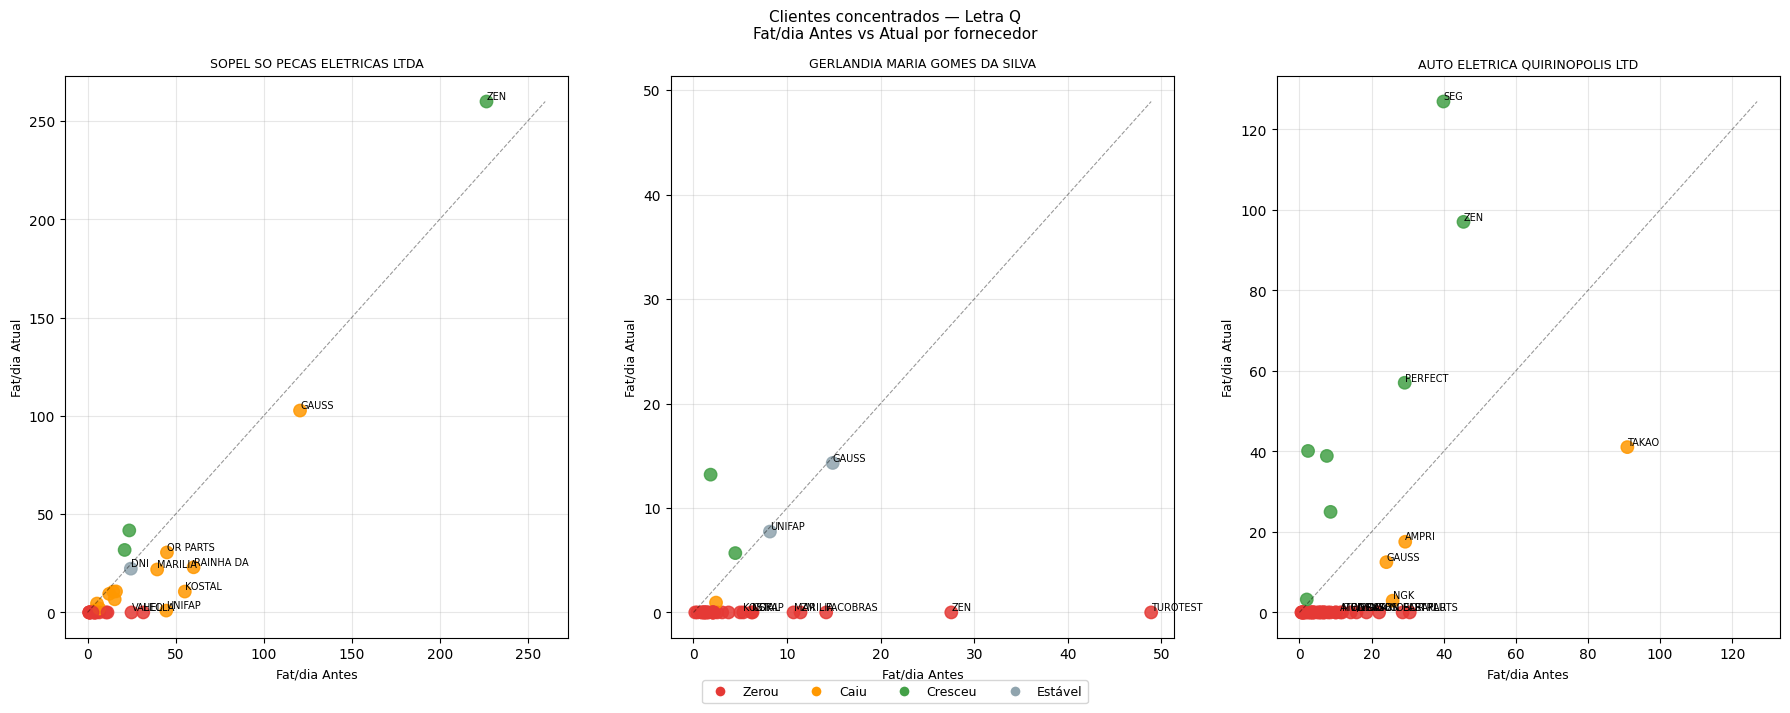

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

for ax, cod_Q in zip(axes, clientes_concentrados_Q):
    sub = cf_80_Q[cf_80_Q['codcli'].astype(str) == cod_Q].copy()
    sub = sub[sub['a_vl_d'] > 0]
    nome = sub['nome'].iloc[0][:30]
    
    # Cores por status
    cores = []
    for _, row in sub.iterrows():
        if row['d_vl_d'] == 0:
            cores.append('#e53935')  # vermelho — zerou
        elif row['Δ vl_pct'] <= -10:
            cores.append('#ff9800')  # laranja — caiu
        elif row['Δ vl_pct'] >= 10:
            cores.append('#43a047')  # verde — cresceu
        else:
            cores.append('#90a4ae')  # cinza — estável

    scatter = ax.scatter(sub['a_vl_d'], sub['d_vl_d'], 
                         c=cores, s=80, alpha=0.85, zorder=2)
    
    # Linha diagonal = sem mudança
    max_val = max(sub['a_vl_d'].max(), sub['d_vl_d'].max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=0.8, alpha=0.4, label='Sem mudança')
    
    # Labels nos pontos maiores
    for _, row in sub[sub['a_vl_d'] > sub['a_vl_d'].quantile(0.7)].iterrows():
        ax.annotate(row['fantasia'], (row['a_vl_d'], row['d_vl_d']),
                    fontsize=7, ha='left', va='bottom')
    
    ax.set_xlabel("Fat/dia Antes", fontsize=9)
    ax.set_ylabel("Fat/dia Atual", fontsize=9)
    ax.set_title(nome, fontsize=9)
    ax.grid(alpha=0.3)

# Legenda manual
from matplotlib.lines import Line2D
legenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e53935', markersize=8, label='Zerou'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff9800', markersize=8, label='Caiu'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#43a047', markersize=8, label='Cresceu'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#90a4ae', markersize=8, label='Estável'),
]
fig.legend(handles=legenda, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Clientes concentrados — Letra Q\nFat/dia Antes vs Atual por fornecedor", fontsize=11)
plt.tight_layout()
plt.savefig('dispersao_Q.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#OBSERVAÇÃO-
# o CV mede quanto as quedas estão dispersas em relação a média. 
# um cv baixo indica que a queda foi proporcionalmente homogênea entre todos os fornecedores do cliente.
# Um CV alto indica que a queda está concentrada em fornecedores específicos

# O threshold escolhido foi 0.5, se CV for menor que 0.5, classifica como normalizada. Se for maior, concentrada.

# Uma análise mais rigorosa exigiria mais observações por fornecedor para aplicar testes estatísticos formais.